# 02 - Analysis: communities, item importance, and figures

Loads networks from `artifacts/`, detects opinion-based groups (Girvan-Newman and Louvain), ranks item importance, and prepares analysis outputs.

After this notebook, run `python code/regenerate_figures.py` from the repo root for seaborn charts and Cytoscape.js screenshots under `figures/`.


In [1]:
from pathlib import Path
import json
import copy
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from networkx.algorithms.community import girvan_newman, louvain_communities, modularity

ROOT = Path.cwd()
if not (ROOT / "Survey_Results_UC.csv").exists() and (ROOT.parent / "Survey_Results_UC.csv").exists():
    ROOT = ROOT.parent
elif not (ROOT / "Survey_Results_UC.csv").exists() and (ROOT / ".." / "Survey_Results_UC.csv").exists():
    ROOT = (ROOT / "..").resolve()
ART = ROOT / 'artifacts'
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')

G = nx.read_graphml(ART / 'agent_network.graphml')
G_att = nx.read_graphml(ART / 'attitude_network.graphml')
kept = pd.read_csv(ART / 'encoded_respondents.csv')
item_stats = pd.read_csv(ART / 'item_stats.csv')
theta_info = json.loads((ART / 'chosen_theta.json').read_text())
prep = json.loads((ART / 'prep_meta.json').read_text())

item_cols = [c for c in kept.columns if c not in ('respondent_id', 'completeness')]
themes = {'T': [c for c in item_cols if c.startswith('T')],
          'E': [c for c in item_cols if c.startswith('E')],
          'S': [c for c in item_cols if c.startswith('S')],
          'V': [c for c in item_cols if c.startswith('V')]}

print(G)
print(G_att)
print('theta', theta_info['theta'])


Graph with 87 nodes and 456 edges
Graph with 60 nodes and 498 edges
theta 41.5


## Graph metrics

,name,n_nodes,n_edges,density,n_components,giant_size,giant_frac,avg_degree,avg_clustering,avg_shortest_path_giant
0,agent,87,456,0.121893,18,70,0.804598,10.482759,0.447263,2.273706
1,attitude,60,498,0.281356,17,44,0.733333,16.600000,0.605598,1.476744


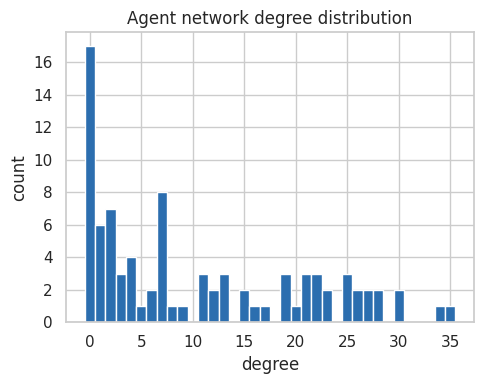

In [2]:
def summarize_graph(G, name):
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    giant = G.subgraph(comps[0]).copy()
    degrees = [d for _, d in G.degree()]
    info = {
        'name': name,
        'n_nodes': G.number_of_nodes(),
        'n_edges': G.number_of_edges(),
        'density': nx.density(G),
        'n_components': len(comps),
        'giant_size': len(comps[0]),
        'giant_frac': len(comps[0]) / G.number_of_nodes(),
        'avg_degree': float(np.mean(degrees)),
        'avg_clustering': nx.average_clustering(G, weight=None),
        'avg_shortest_path_giant': float(nx.average_shortest_path_length(giant)) if giant.number_of_nodes() > 1 else 0.0,
    }
    return info

metrics = [summarize_graph(G, 'agent'), summarize_graph(G_att, 'attitude')]
metrics_df = pd.DataFrame(metrics)
display(metrics_df)
metrics_df.to_csv(ART / 'graph_metrics.csv', index=False)

fig, ax = plt.subplots(figsize=(5, 4))
deg = [d for _, d in G.degree()]
ax.hist(deg, bins=range(0, max(deg) + 2), color='#2c6eaf', edgecolor='white', align='left')
ax.set_title('Agent network degree distribution')
ax.set_xlabel('degree')
ax.set_ylabel('count')
fig.tight_layout()
fig.savefig(FIG / 'agent_degree_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

## Community detection (Louvain + Girvan-Newman)

Louvain communities=20, modularity=0.2751
sizes [37, 29, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


Girvan-Newman parts [64, 4, 2]
         mean_opinion    mean_T    mean_E    mean_S    mean_V  size
louvain                                                            
0            0.702153  0.576720  0.536808  0.821429  0.870785    37
1            0.493015  0.440969  0.424138  0.562176  0.544828    29
2            0.577083  0.483333  0.458333  0.550000  0.816667     4
3            0.412281  0.428571  0.233333  0.500000  0.500000     1
4            0.625000  0.700000  0.466667  0.700000  0.633333     1
5            0.450000  0.633333  0.200000  0.366667  0.600000     1
6            0.341667  0.600000  0.200000  0.233333  0.333333     1
7            0.558333  0.400000  0.600000  0.733333  0.500000     1
8            0.550847  0.392857  0.566667  0.533333  0.700000     1
9            0.455556  0.500000  0.366667  0.500000       NaN     1
10           0.516949  0.250000  0.433333  0.366667  1.000000     1
11           0.375000  0.200000  0.133333  0.533333  0.633333     1
12           0.40

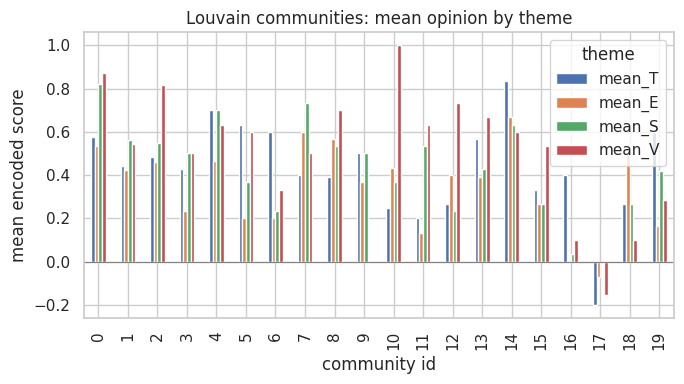

285

In [3]:
# Louvain on weighted agent graph
louvain_sets = louvain_communities(G, weight='weight', seed=42)
louvain_sets = sorted(louvain_sets, key=len, reverse=True)
louvain_map = {}
for cid, nodes in enumerate(louvain_sets):
    for n in nodes:
        louvain_map[n] = cid

Q_louvain = modularity(G, louvain_sets, weight='weight')
print(f'Louvain communities={len(louvain_sets)}, modularity={Q_louvain:.4f}')
print('sizes', [len(s) for s in louvain_sets])

# Girvan-Newman: first meaningful bipartition of the giant component
giant_nodes = max(nx.connected_components(G), key=len)
G_giant = G.subgraph(giant_nodes).copy()


def most_central_edge(graph):
    centrality = nx.edge_betweenness_centrality(graph, weight=None)
    return max(centrality, key=centrality.get)


gn_iter = girvan_newman(G_giant, most_valuable_edge=most_central_edge)
gn_partition = None
for communities in gn_iter:
    parts = sorted(communities, key=len, reverse=True)
    # skip trivial tiny splinters (<5% of giant)
    if len(parts[0]) < 0.95 * G_giant.number_of_nodes() and len(parts[-1]) >= max(3, 0.05 * G_giant.number_of_nodes()):
        gn_partition = parts
        break
    if len(parts) >= 2 and len(parts[1]) >= 3:
        gn_partition = parts
        break

if gn_partition is None:
    gn_partition = [set(G_giant.nodes())]

gn_map = {n: -1 for n in G.nodes()}  # -1 = outside giant / unassigned
for cid, nodes in enumerate(gn_partition):
    for n in nodes:
        gn_map[n] = cid

print('Girvan-Newman parts', [len(p) for p in gn_partition])

for n in G.nodes():
    G.nodes[n]['louvain'] = int(louvain_map[n])
    G.nodes[n]['girvan_newman'] = int(gn_map[n])

nx.write_graphml(G, ART / 'agent_network_communities.graphml')

comm_df = pd.DataFrame({
    'respondent_id': list(G.nodes()),
    'louvain': [G.nodes[n]['louvain'] for n in G.nodes()],
    'girvan_newman': [G.nodes[n]['girvan_newman'] for n in G.nodes()],
    'mean_opinion': [G.nodes[n].get('mean_opinion', np.nan) for n in G.nodes()],
    'mean_T': [G.nodes[n].get('mean_T', np.nan) for n in G.nodes()],
    'mean_E': [G.nodes[n].get('mean_E', np.nan) for n in G.nodes()],
    'mean_S': [G.nodes[n].get('mean_S', np.nan) for n in G.nodes()],
    'mean_V': [G.nodes[n].get('mean_V', np.nan) for n in G.nodes()],
})
comm_df.to_csv(ART / 'communities.csv', index=False)

profile = comm_df.groupby('louvain')[['mean_opinion', 'mean_T', 'mean_E', 'mean_S', 'mean_V']].mean()
profile['size'] = comm_df.groupby('louvain').size()
print(profile)
profile.to_csv(ART / 'community_theme_profiles.csv')

fig, ax = plt.subplots(figsize=(7, 4))
profile[['mean_T', 'mean_E', 'mean_S', 'mean_V']].plot(kind='bar', ax=ax)
ax.set_title('Louvain communities: mean opinion by theme')
ax.set_xlabel('community id')
ax.set_ylabel('mean encoded score')
ax.axhline(0, color='gray', lw=0.8)
ax.legend(title='theme')
fig.tight_layout()
fig.savefig(FIG / 'community_theme_profiles.png', dpi=200, bbox_inches='tight')
plt.show()

(ART / 'community_meta.json').write_text(json.dumps({
    'n_louvain': len(louvain_sets),
    'modularity_louvain': Q_louvain,
    'louvain_sizes': [len(s) for s in louvain_sets],
    'girvan_newman_sizes': [len(p) for p in gn_partition],
}, indent=2))

## Item importance (response shuffle)

For each item, shuffle responses across respondents, rebuild Louvain communities on a re-thresholded similarity graph is expensive. Following Dinkelberg et al., we measure how much shuffling an item changes distances relative to the baseline community assignment via within-community dispersion (WSS-style) and agreement of partitions (ARI vs baseline) after re-clustering on a cheap distance matrix with that item removed/shuffled.

Practical proxy used here: shuffle column $f$, recompute pairwise Manhattan distances on the opinion matrix, run hierarchical-style Louvain on a knn-thresholded distance graph, and score disruption as $1 - ARI$ vs baseline Louvain labels. Higher disruption => more important item.

processed 10/60 items


processed 20/60 items


processed 30/60 items


processed 40/60 items


processed 50/60 items


processed 60/60 items
item                                                                                                      full_label theme  mean_ari_after_shuffle  importance
 E04                                E04. High-quality online learning can effectively complement classroom teaching.     E                0.653082    0.346918
 E01                   E01. Project-based learning develops deeper understanding than examination-oriented learning.     E                0.679125    0.320875
 T02                                T02. Generative AI tools should be allowed as learning aids in higher education.     T                0.683518    0.316482
 S15                      S15. Building public trust is essential for responsible adoption of emerging technologies.     S                0.685780    0.314220
 T14                                                T14. Social media algorithms contribute to opinion polarization.     T                0.691847    0.308153
 V06                    

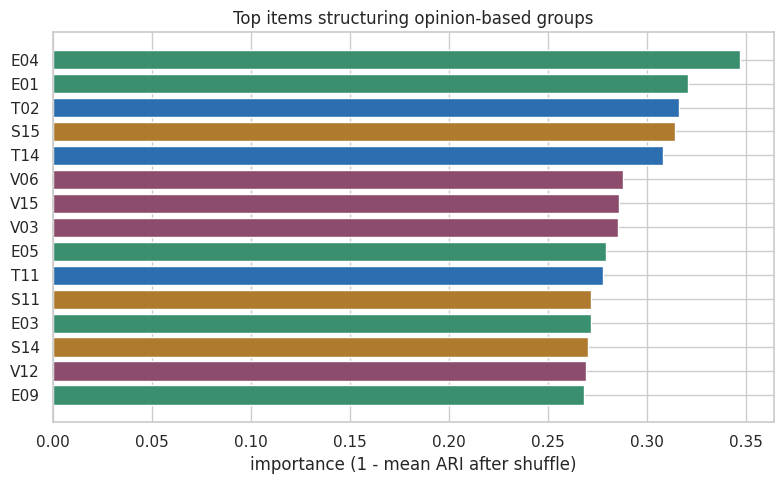

In [4]:
from sklearn.metrics import adjusted_rand_score

ids = kept['respondent_id'].astype(str).tolist()
X = kept[item_cols].to_numpy(dtype=float)
base_labels = np.array([louvain_map[i] for i in ids])
theta = float(theta_info['theta'])
rng = np.random.default_rng(42)


def similarity_from_matrix(Xm, min_overlap=20):
    n = Xm.shape[0]
    S = np.full((n, n), np.nan)
    for i in range(n):
        for j in range(i + 1, n):
            mask = np.isfinite(Xm[i]) & np.isfinite(Xm[j])
            n_ij = int(mask.sum())
            if n_ij < min_overlap:
                continue
            S[i, j] = S[j, i] = n_ij - np.abs(Xm[i, mask] - Xm[j, mask]).sum()
    return S


def louvain_from_S(S, theta, node_ids):
    H = nx.Graph()
    H.add_nodes_from(node_ids)
    iu, ju = np.triu_indices(len(node_ids), k=1)
    for i, j in zip(iu, ju):
        s = S[i, j]
        if np.isfinite(s) and s >= theta:
            H.add_edge(node_ids[i], node_ids[j], weight=float(s))
    if H.number_of_edges() == 0:
        return np.arange(len(node_ids))
    parts = louvain_communities(H, weight='weight', seed=0)
    lab = {}
    for cid, nodes in enumerate(parts):
        for n in nodes:
            lab[n] = cid
    # isolated nodes get unique labels
    next_id = len(parts)
    out = []
    for n in node_ids:
        if n in lab:
            out.append(lab[n])
        else:
            out.append(next_id)
            next_id += 1
    return np.array(out)


importance_rows = []
n_shuffles = 3
for fi, col in enumerate(item_cols):
    aris = []
    for _ in range(n_shuffles):
        Xm = X.copy()
        col_vals = Xm[:, fi].copy()
        rng.shuffle(col_vals)
        Xm[:, fi] = col_vals
        S_shuf = similarity_from_matrix(Xm)
        labels = louvain_from_S(S_shuf, theta, ids)
        aris.append(adjusted_rand_score(base_labels, labels))
    mean_ari = float(np.mean(aris))
    importance_rows.append({
        'item': col.split('.')[0].strip(),
        'full_label': col,
        'theme': col[0],
        'mean_ari_after_shuffle': mean_ari,
        'importance': 1.0 - mean_ari,
    })
    if (fi + 1) % 10 == 0:
        print(f'processed {fi + 1}/{len(item_cols)} items')

imp_df = pd.DataFrame(importance_rows).sort_values('importance', ascending=False)
imp_df.to_csv(ART / 'item_importance.csv', index=False)
print(imp_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
top = imp_df.head(15)
colors = {'T': '#2c6eaf', 'E': '#3a8f6e', 'S': '#b07a2e', 'V': '#8b4d6b'}
ax.barh(top['item'][::-1], top['importance'][::-1], color=[colors[t] for t in top['theme'][::-1]])
ax.set_xlabel('importance (1 - mean ARI after shuffle)')
ax.set_title('Top items structuring opinion-based groups')
fig.tight_layout()
fig.savefig(FIG / 'item_importance_top15.png', dpi=200, bbox_inches='tight')
plt.show()

## Contested items and theme summaries

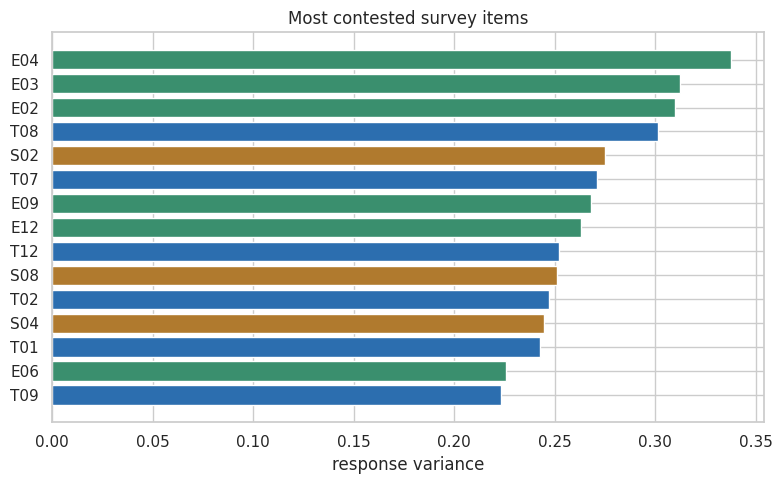

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
top_var = item_stats.head(15)
ax.barh(top_var['item'][::-1], top_var['variance'][::-1],
        color=[colors[t] for t in top_var['theme'][::-1]])
ax.set_xlabel('response variance')
ax.set_title('Most contested survey items')
fig.tight_layout()
fig.savefig(FIG / 'contested_items_variance.png', dpi=200, bbox_inches='tight')
plt.show()

# Attitude network Louvain for viz attributes
att_parts = louvain_communities(G_att, weight='weight', seed=42)
att_map = {}
for cid, nodes in enumerate(att_parts):
    for n in nodes:
        att_map[n] = cid
for n in G_att.nodes():
    G_att.nodes[n]['att_community'] = int(att_map.get(n, -1))
nx.write_graphml(G_att, ART / 'attitude_network_communities.graphml')

## Node importance: typical students and bridging beliefs

Degree centrality on the agent network identifies the most *typical* (high-degree) respondents and the *outliers* (degree 0). Betweenness centrality on the attitude network identifies the statements that sit on the shortest co-endorsement paths between clusters, i.e. the beliefs that *bridge* distinct opinion groups.


In [ ]:
# --- Degree centrality: agent network (typical vs. outlier respondents) ---
deg = dict(G.degree())
deg_df = pd.DataFrame([
    {'respondent_id': n, 'degree': d,
     'mean_opinion': G.nodes[n].get('mean_opinion', np.nan),
     'louvain': G.nodes[n].get('louvain', -1)}
    for n, d in deg.items()
]).sort_values('degree', ascending=False)
deg_df.to_csv(ART / 'agent_degree_centrality.csv', index=False)

print('Most typical respondents (highest degree):')
print(deg_df.head(10).to_string(index=False))

isolates = deg_df[deg_df['degree'] == 0]
print(f'\nOutlier respondents (degree = 0): {len(isolates)}')
print(f'mean_opinion -> min={isolates.mean_opinion.min():.3f}, '
      f'median={isolates.mean_opinion.median():.3f}, max={isolates.mean_opinion.max():.3f}')

for n in G.nodes():
    G.nodes[n]['degree'] = int(deg[n])
nx.write_graphml(G, ART / 'agent_network_communities.graphml')

# --- Attitude network: betweenness (bridge items connecting clusters) ---
bc = nx.betweenness_centrality(G_att, weight='weight', normalized=True)

att_cent = pd.DataFrame([
    {'item': n,
     'full_label': G_att.nodes[n].get('full_label', ''),
     'theme': G_att.nodes[n].get('theme', ''),
     'degree': G_att.degree(n),
     'betweenness': bc[n]}
    for n in G_att.nodes()
])
att_cent.to_csv(ART / 'attitude_centrality.csv', index=False)

print('\nBridge items connecting clusters (top betweenness):')
print(att_cent.sort_values('betweenness', ascending=False)
      .head(10)[['item', 'theme', 'betweenness']].to_string(index=False))

for n in G_att.nodes():
    G_att.nodes[n]['betweenness'] = float(bc[n])
nx.write_graphml(G_att, ART / 'attitude_network_communities.graphml')


## Network figures

Primary interactive path: open `artifacts/agent_network_communities.graphml` and `artifacts/attitude_network_communities.graphml` in Cytoscape (Organic / force-directed layout; color by `louvain` or `theme`; edge width by `weight`).

Below we also export static PNGs suitable for the PDF report.

/tmp/ipykernel_37279/1615883134.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(len(uniq), 1))


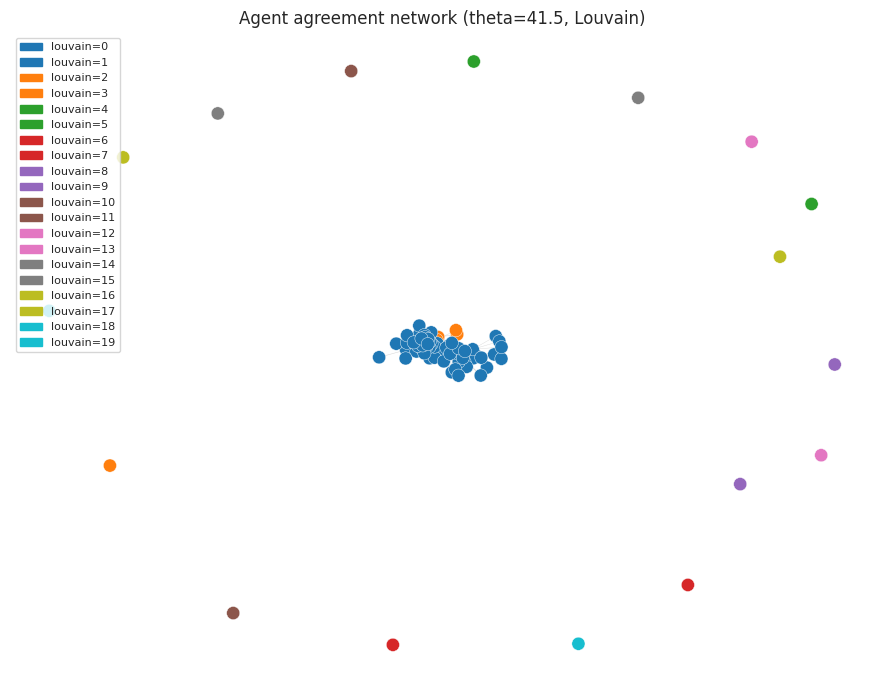

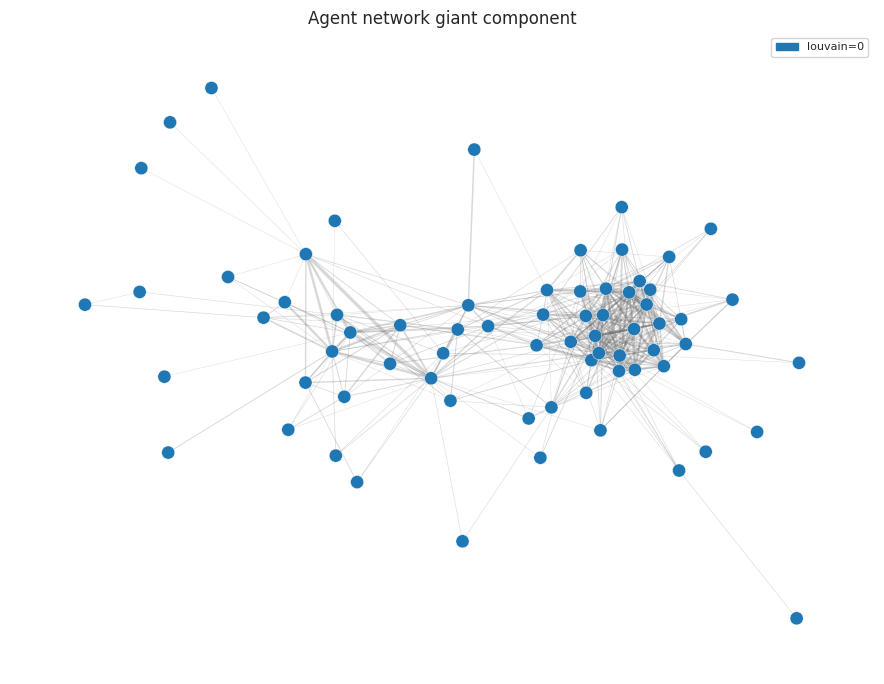

/tmp/ipykernel_37279/1615883134.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set2', max(len(uniq), 1))


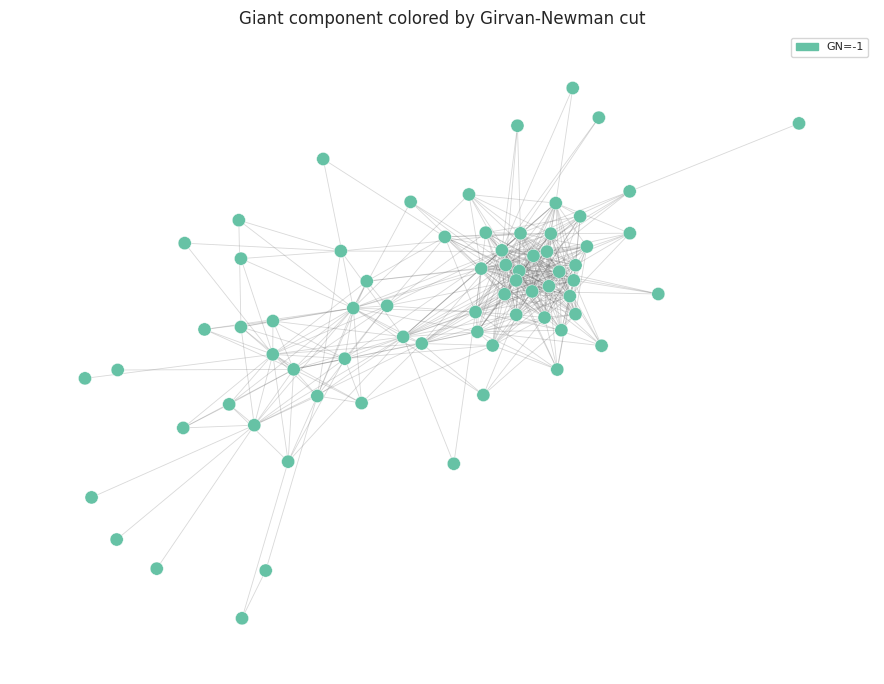

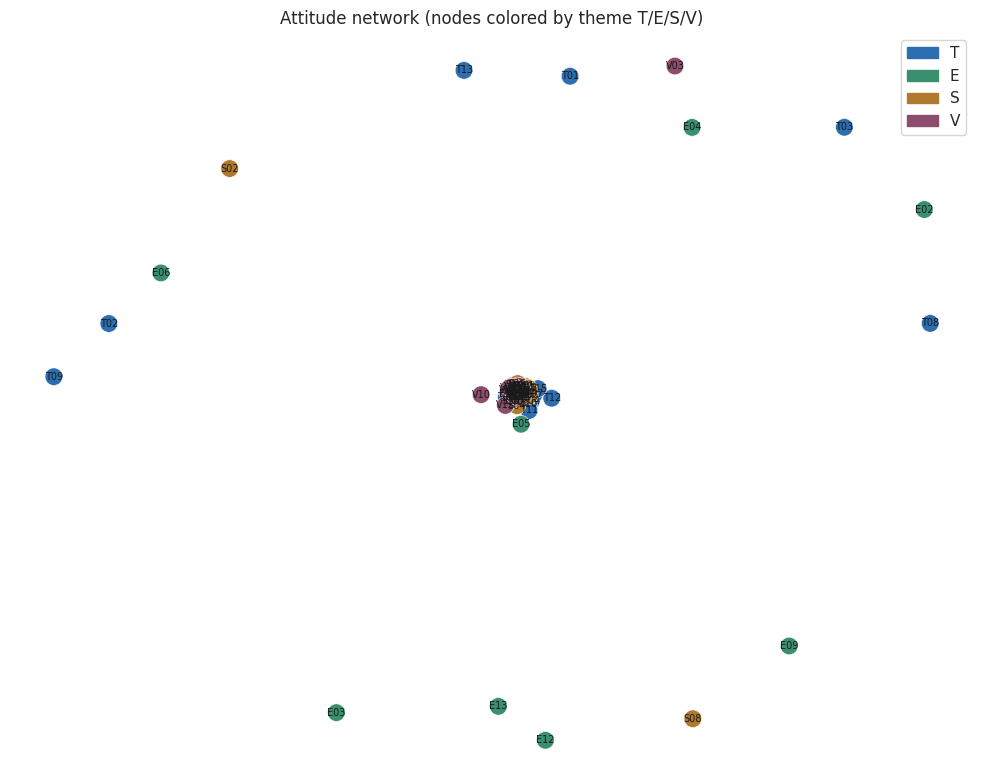

Wrote network PNGs and community GraphML for Cytoscape import.
Cytoscape checklist:
  1. File -> Import -> Network from File -> artifacts/agent_network_communities.graphml
  2. Style: node fill by louvain (Discrete), size by mean_opinion
  3. Edge width by weight; Layout -> Prefuse Force Directed / Organic
  4. File -> Export -> Network to Image -> figures/


In [6]:
def draw_agent_network(G, attr='louvain', path=FIG / 'agent_network_louvain.png', title='Agent opinion network'):
    pos = nx.spring_layout(G, weight='weight', seed=42, k=2.2 / np.sqrt(G.number_of_nodes()))
    labels = [G.nodes[n].get(attr, 0) for n in G.nodes()]
    uniq = sorted(set(labels))
    cmap = plt.cm.get_cmap('tab10', max(len(uniq), 1))
    color_index = {u: i for i, u in enumerate(uniq)}
    node_colors = [cmap(color_index[v]) for v in labels]
    weights = np.array([d.get('weight', 1.0) for _, _, d in G.edges(data=True)], dtype=float)
    if len(weights):
        wmin, wmax = weights.min(), weights.max()
        widths = 0.3 + 2.0 * (weights - wmin) / (wmax - wmin + 1e-9)
    else:
        widths = 1.0

    fig, ax = plt.subplots(figsize=(9, 7))
    nx.draw_networkx_edges(G, pos, ax=ax, width=widths, alpha=0.25, edge_color='#666666')
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=90, linewidths=0.3, edgecolors='white')
    ax.set_title(title)
    ax.axis('off')
    handles = [mpatches.Patch(color=cmap(color_index[u]), label=f'{attr}={u}') for u in uniq]
    ax.legend(handles=handles, loc='best', fontsize=8, frameon=True)
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches='tight')
    plt.show()


draw_agent_network(G, 'louvain', FIG / 'agent_network_louvain.png',
                   title=f'Agent agreement network (theta={theta}, Louvain)')
draw_agent_network(G_giant, 'girvan_newman' if False else 'louvain', FIG / 'agent_network_giant.png',
                   title='Agent network giant component')

# color giant by GN label
pos = nx.spring_layout(G_giant, weight='weight', seed=7, k=2.0 / np.sqrt(G_giant.number_of_nodes()))
gn_labels = [G_giant.nodes[n].get('girvan_newman', -1) for n in G_giant.nodes()]
uniq = sorted(set(gn_labels))
cmap = plt.cm.get_cmap('Set2', max(len(uniq), 1))
color_index = {u: i for i, u in enumerate(uniq)}
node_colors = [cmap(color_index[v]) for v in gn_labels]
fig, ax = plt.subplots(figsize=(9, 7))
nx.draw_networkx_edges(G_giant, pos, ax=ax, alpha=0.25, edge_color='#666666', width=0.6)
nx.draw_networkx_nodes(G_giant, pos, ax=ax, node_color=node_colors, node_size=90, linewidths=0.3, edgecolors='white')
ax.set_title('Giant component colored by Girvan-Newman cut')
ax.axis('off')
handles = [mpatches.Patch(color=cmap(color_index[u]), label=f'GN={u}') for u in uniq]
ax.legend(handles=handles, loc='best', fontsize=8)
fig.tight_layout()
fig.savefig(FIG / 'agent_network_girvan_newman.png', dpi=220, bbox_inches='tight')
plt.show()

# Attitude network by theme
pos_a = nx.spring_layout(G_att, weight='weight', seed=3, k=1.8 / np.sqrt(G_att.number_of_nodes()))
theme_color = {'T': '#2c6eaf', 'E': '#3a8f6e', 'S': '#b07a2e', 'V': '#8b4d6b'}
node_colors = [theme_color.get(G_att.nodes[n].get('theme', 'T'), '#333') for n in G_att.nodes()]
fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_edges(G_att, pos_a, ax=ax, alpha=0.15, edge_color='#777777', width=0.5)
nx.draw_networkx_nodes(G_att, pos_a, ax=ax, node_color=node_colors, node_size=160, linewidths=0.4, edgecolors='white')
nx.draw_networkx_labels(G_att, pos_a, ax=ax, font_size=7)
ax.set_title('Attitude network (nodes colored by theme T/E/S/V)')
ax.axis('off')
handles = [mpatches.Patch(color=c, label=t) for t, c in theme_color.items()]
ax.legend(handles=handles, loc='best')
fig.tight_layout()
fig.savefig(FIG / 'attitude_network_themes.png', dpi=220, bbox_inches='tight')
plt.show()

print('Wrote network PNGs and community GraphML for Cytoscape import.')
print('Cytoscape checklist:')
print('  1. File -> Import -> Network from File -> artifacts/agent_network_communities.graphml')
print('  2. Style: node fill by louvain (Discrete), size by mean_opinion')
print('  3. Edge width by weight; Layout -> Prefuse Force Directed / Organic')
print('  4. File -> Export -> Network to Image -> figures/')